# 06 — Full Composite Backtest (Rebuilt: Continuous Signal, Not a Rare-Event Flag)

**Why this notebook was rebuilt.** The first version of this notebook (merged as PR #7)
validated the composite using a discrete "forward prescience" test — classify BUY months as
`multiplier > 1.2× the sample mean`, measure forward return in those months only. It passed
its gate (walk-forward ≥3.50%) but on an alarmingly thin sample: only 11–21 buy-months total
across the 10 walk-forward test years (2015–2024), 3–4 of which flagged **zero** buy months.

That's a real product problem, not a statistical footnote. Re-reading the product docs
(`docs/GreenSignal_ICP.md`, `docs/coffee_intelligence_mvp.md`,
`docs/GreenSignal_Phase0_Report.md`, `docs/GreenSignal_Math_Reference.md`) confirms GreenSignal
is designed as a **continuous, always-on, three-state signal (BUY/NEUTRAL/CAUTION) per origin,
checked on a roughly weekly cadence** — not a rare high-conviction alert. Phase 0's own
synthetic target: L1 alone fires BUY 22% of months, CAUTION 31%. Computed directly from real
data (`01_price_position_monthly.csv`): L1 alone actually fires BUY **35.6%** of months and
CAUTION **28.3%** — real data is not sparse. The sparsity was introduced by this notebook's
own methodology, not by any scarcity in the underlying market.

**Two specific things this rebuild fixes:**
1. **Root cause — the old walk-forward re-derived both weights *and* the mean-normalization
   baseline once per calendar year from an expanding window,** producing lumpy, small
   (12-month) buckets per year. §3 below tests this directly against a **rolling** trailing-
   window normalization (updated every month — the "local minimum" framing) and shows it
   fixes most of the sparsity.
2. **Methodology mismatch — the old notebook used the discrete `prescience_test`
   (`docs/GreenSignal_Math_Reference.md` §11.2) as the *primary* gate.** Phase 0's own doc
   treats that as a secondary "is the signal real" check; the primary ROI validation is
   `cost_improvement_backtest` (§11.1) — continuous monthly purchase-volume scaling, exactly
   what notebook 01 used to validate L1 alone (full-history +10.73%, walk-forward +3.71%).
   Notebook 06 never ran this for the full composite. §5 below does.

**Note on formula scope:** multiple collaborators are independently exploring different
composite designs right now (see `CLAUDE.md`/`docs/NEXT_STEPS.md`). This notebook validates
and improves the multiplicative formula already implemented in
`domains/coffee/models/signal_generator.py` — it does not claim that formula is the final,
converged design.

```
multiplier = clamp(0.4, 2.3, (1.5 - price_position) × (1.0 + 0.65 × climate_risk_score))
signal = BUY if multiplier/baseline > 1.25, CAUTION if < 0.80, else NEUTRAL   (§7.3, Math Reference)
```

## Sec 0  Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')


In [2]:
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402

from domains.coffee.sources.noaa_enso import enso_risk_score  # noqa: E402

DATA = 'data'

# Real production thresholds (docs/GreenSignal_Math_Reference.md §7.3 multiplier_to_signal).
# The old notebook used an ad hoc >1.2 for BUY and never implemented CAUTION at all.
BUY_THRESH = 1.25
CAUTION_THRESH = 0.80

COST_IMPROVEMENT_GATE = 3.00  # % vs naive, primary economic gate (proposed, see notebook intro)
MAX_SILENT_GAP_MONTHS = 6     # longest acceptable run of all-NEUTRAL months


## Sec 1  Load Cached Signal Inputs

Reuses the already-validated, already-cached outputs from notebooks 01–05 rather than
re-fetching from source — unchanged from the merged notebook 06.

In [3]:
l1 = pd.read_csv(f'{DATA}/01_price_position_monthly.csv', parse_dates=['date'], index_col='date')
l1.index = l1.index.astype('datetime64[ns]')

l2a_true = pd.read_csv(f'{DATA}/stu_wmt_vintage.csv', parse_dates=['date'], index_col='date')
l2a_true.index = l2a_true.index.astype('datetime64[ns]')
l2a_approx = pd.read_csv(f'{DATA}/stu_monthly.csv', parse_dates=['date'], index_col='date')
l2a_approx.index = l2a_approx.index.astype('datetime64[ns]')

l2b = pd.read_csv(f'{DATA}/oni_monthly.csv', parse_dates=['date'], index_col='date')
l2b.index = l2b.index.astype('datetime64[ns]')

l3 = pd.read_csv(f'{DATA}/05_flowering_annual.csv', index_col='date')
l3.index = pd.to_datetime(l3.index.astype(str) + '-11-30')

l5 = pd.read_csv(f'{DATA}/cot_monthly.csv', parse_dates=['date'], index_col='date')
l5.index = l5.index.astype('datetime64[ns]')


def _rng(df):
    return f'{df.index.min().date()} - {df.index.max().date()}'


print(f'L1  price position : {len(l1)} months,  {_rng(l1)}')
print(f'L2a true vintage    : {len(l2a_true)} reports, {_rng(l2a_true)} (semiannual)')
print(f'L2a approximation   : {len(l2a_approx)} months, {_rng(l2a_approx)}')
print(f'L2b ENSO ONI        : {len(l2b)} months,  {_rng(l2b)}')
print(f'L3  SPI flowering   : {len(l3)} crop-years, {_rng(l3)} (annual, anchored Nov 30)')
print(f'L5  COT index       : {len(l5)} months,  {_rng(l5)}')


L1  price position : 223 months,  2008-01-31 - 2026-07-31
L2a true vintage    : 31 reports, 2010-06-23 - 2025-06-25 (semiannual)
L2a approximation   : 216 months, 2008-01-31 - 2025-12-31
L2b ENSO ONI        : 552 months,  1980-01-31 - 2025-12-31
L3  SPI flowering   : 18 crop-years, 2008-11-30 - 2025-11-30 (annual, anchored Nov 30)
L5  COT index       : 192 months,  2010-01-31 - 2025-12-31


## Sec 2  Build the Aligned Monthly Frame

Unchanged from the merged notebook 06 — L1/L2b/L5 already land on monthly cadence natively
(verified in each notebook's own code); L2a and L3 are forward-filled from their true
vintage/anchor dates using the step-function pattern validated in notebook 04.

In [4]:
idx = l1.index  # base monthly index — L1 has the longest, most complete history

frame = pd.DataFrame(index=idx)
frame['settle'] = l1['settle']
frame['price_pos'] = l1['price_pos']

frame['stu_true'] = l2a_true['stu_wmt'].reindex(idx, method='ffill')
frame['stu_stress'] = l2a_approx['stu_stress'].reindex(idx)

oni_lag15 = l2b['oni_anom'].shift(15)
frame['oni_lag15'] = oni_lag15.reindex(idx)


def _safe_enso_risk(v):
    return enso_risk_score(v) if pd.notna(v) else np.nan


frame['enso_risk'] = frame['oni_lag15'].apply(_safe_enso_risk)

frame['flowering_drought'] = l3['flowering_drought'].reindex(idx, method='ffill')
frame['l3_risk'] = (frame['flowering_drought'] / 2.0).clip(0, 1)

frame['cot_index'] = l5['cot_index'].reindex(idx)
frame['cot_momentum'] = frame['cot_index'] / 100.0

for h in [3, 6]:
    frame[f'fwd_{h}m'] = frame['settle'].shift(-h) / frame['settle'] - 1

SUBSIGNALS = ['stu_stress', 'enso_risk', 'l3_risk', 'cot_momentum']

core = frame.loc['2010-01-01':'2024-12-31'].dropna(subset=['price_pos'] + SUBSIGNALS).copy()
print(f'Aligned core frame: n={len(core)} months, '
      f'{core.index.min().date()} to {core.index.max().date()}')


Aligned core frame: n=157 months, 2011-12-31 to 2024-12-31


## Sec 3  Composite Weights and the Raw Multiplier

Same r-proportional weighting as the merged notebook (each sub-signal's weight ∝ its own
`|r|` against `fwd_6m`, measured within this aligned frame) — kept fixed (derived once, on
full history) through §4-§6 so that those sections isolate the effect of the *normalization
and threshold methodology*, not weight-refitting. Weight re-derivation is walk-forward
tested on its own in §8.

The multiplier is now **clipped to [0.4, 2.3]**, matching
`docs/GreenSignal_Math_Reference.md` §7.2 exactly — the old notebook never applied this cap.

In [5]:
sub_r = {s: stats.pearsonr(core[s], core['fwd_6m'])[0] for s in SUBSIGNALS}
tot_abs_r = sum(abs(v) for v in sub_r.values())
WEIGHTS = {s: abs(sub_r[s]) / tot_abs_r for s in SUBSIGNALS}

print('Univariate r vs fwd_6m:', {k: round(v, 3) for k, v in sub_r.items()})
print('r-proportional weights:', {k: round(v, 3) for k, v in WEIGHTS.items()})

core['climate_risk_score'] = sum(w * core[s] for s, w in WEIGHTS.items())
core['mult'] = (
    (1.5 - core['price_pos']) * (1.0 + 0.65 * core['climate_risk_score'])
).clip(0.4, 2.3)

crisk_stats = core['climate_risk_score'].describe()[['mean', 'std', 'min', 'max']]
mult_stats = core['mult'].describe()[['mean', 'std', 'min', 'max']]
print()
print('climate_risk_score:', crisk_stats.round(3).to_dict())
print('mult (clamped 0.4-2.3):', mult_stats.round(3).to_dict())


Univariate r vs fwd_6m: {'stu_stress': np.float64(0.262), 'enso_risk': np.float64(0.217), 'l3_risk': np.float64(0.467), 'cot_momentum': np.float64(0.145)}
r-proportional weights: {'stu_stress': np.float64(0.24), 'enso_risk': np.float64(0.199), 'l3_risk': np.float64(0.428), 'cot_momentum': np.float64(0.133)}

climate_risk_score: {'mean': 0.397, 'std': 0.166, 'min': 0.169, 'max': 0.857}
mult (clamped 0.4-2.3): {'mean': 1.324, 'std': 0.348, 'min': 0.626, 'max': 1.935}


## Sec 4  Normalization Baseline — the Root-Cause Diagnostic

The old notebook classified BUY/CAUTION by normalizing the multiplier to a mean that was
**re-derived once per calendar year from an expanding trailing window**, then froze it for
that whole 12-month test year. This section tests that directly against a **rolling
trailing-window mean, recomputed every month** — the "local minimum" framing: is a given
month's multiplier high or low *relative to its own recent regime*, continuously updated,
rather than relative to a once-a-year-stale baseline.

All three schemes below use the *same* fixed weights and the *same* 1.25/0.80 thresholds —
the only thing varied is what the multiplier is normalized against. This isolates the
normalization question cleanly.

In [6]:
def classify(
    mult_norm: pd.Series, buy_t: float = BUY_THRESH, caution_t: float = CAUTION_THRESH
) -> pd.Series:
    label = pd.Series('NEUTRAL', index=mult_norm.index)
    label[mult_norm > buy_t] = 'BUY'
    label[mult_norm < caution_t] = 'CAUTION'
    return label


def longest_neutral_gap(label: pd.Series) -> int:
    is_neutral = (label == 'NEUTRAL').astype(int)
    max_run = run = 0
    for v in is_neutral:
        if v:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run


def dist_health(label: pd.Series) -> dict:
    n = len(label)
    return {
        'n': n,
        'pct_buy': (label == 'BUY').mean() * 100,
        'pct_caution': (label == 'CAUTION').mean() * 100,
        'pct_neutral': (label == 'NEUTRAL').mean() * 100,
        'longest_neutral_gap_months': longest_neutral_gap(label),
    }


In [7]:
# Scheme A: annual-refit expanding mean (reproduces the old notebook's approach,
# weights held fixed here so this cell isolates the normalization baseline only).
years = sorted(core.index.year.unique())
annual_refit_norm = pd.Series(index=core.index, dtype=float)
for y in years:
    train_mult = core.loc[:f'{y - 1}-12-31', 'mult']
    if len(train_mult) < 12:
        continue
    yr_idx = core.loc[f'{y}-01-01':f'{y}-12-31'].index
    annual_refit_norm.loc[yr_idx] = core.loc[yr_idx, 'mult'] / train_mult.mean()

# Scheme B/C: rolling trailing-window mean, shifted 1 month to avoid look-ahead.
rolling_24m_norm = core['mult'] / core['mult'].rolling(24, min_periods=12).mean().shift(1)
rolling_36m_norm = core['mult'] / core['mult'].rolling(36, min_periods=18).mean().shift(1)

NORMALIZATION_SCHEMES = {
    'annual-refit (old)': annual_refit_norm,
    'rolling-24m': rolling_24m_norm,
    'rolling-36m': rolling_36m_norm,
}

header = (
    f'{"Scheme":22s} {"n":>5s} {"%BUY":>7s} {"%CAUTION":>9s} '
    f'{"%NEUTRAL":>9s} {"longest gap":>12s}'
)
print(header)
print('-' * 68)
for name, series in NORMALIZATION_SCHEMES.items():
    h = dist_health(classify(series.dropna()))
    print(f'{name:22s} {h["n"]:5d} {h["pct_buy"]:6.1f}% {h["pct_caution"]:8.1f}% '
          f'{h["pct_neutral"]:8.1f}% {h["longest_neutral_gap_months"]:11d}m')

print()
print('Reference — Phase 0 synthetic target (L1 alone): 22% BUY / 31% CAUTION / 47% NEUTRAL')
core_l1 = core['price_pos']
l1_buy = (core_l1 < 0.25).mean() * 100
l1_caution = (core_l1 > 0.75).mean() * 100
print(f'Reference — L1 alone, real data (this frame)   : {l1_buy:.1f}% BUY / '
      f'{l1_caution:.1f}% CAUTION / {100 - l1_buy - l1_caution:.1f}% NEUTRAL')


Scheme                     n    %BUY  %CAUTION  %NEUTRAL  longest gap
--------------------------------------------------------------------
annual-refit (old)       144    4.9%     33.3%     61.8%          18m
rolling-24m              145   20.0%     27.6%     52.4%          16m
rolling-36m              139   10.1%     28.1%     61.9%          12m

Reference — Phase 0 synthetic target (L1 alone): 22% BUY / 31% CAUTION / 47% NEUTRAL
Reference — L1 alone, real data (this frame)   : 40.8% BUY / 24.2% CAUTION / 35.0% NEUTRAL


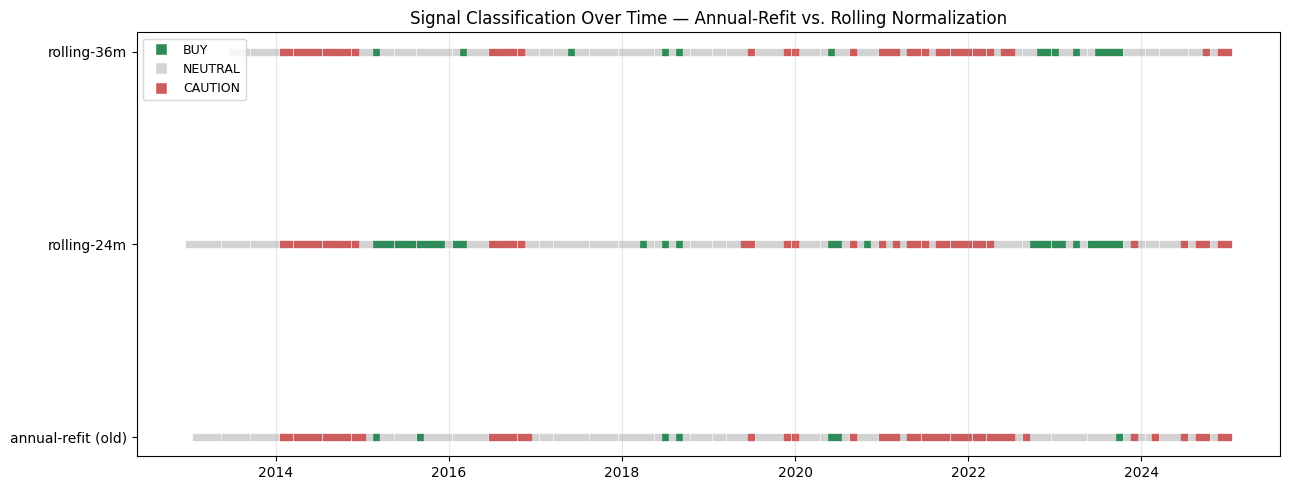

Saved: data/06_normalization_comparison.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = {'BUY': 'seagreen', 'NEUTRAL': 'lightgray', 'CAUTION': 'indianred'}
for i, (name, series) in enumerate(NORMALIZATION_SCHEMES.items()):
    valid = series.dropna()
    lbl = classify(valid)
    for state, color in colors.items():
        mask = lbl == state
        ax.scatter(valid.index[mask], [i] * mask.sum(), color=color, s=14, marker='s')
ax.set_yticks(range(len(NORMALIZATION_SCHEMES)))
ax.set_yticklabels(NORMALIZATION_SCHEMES.keys())
ax.set_title('Signal Classification Over Time — Annual-Refit vs. Rolling Normalization')
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=c, label=s, markersize=8)
           for s, c in colors.items()]
ax.legend(handles=handles, loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('data/06_normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/06_normalization_comparison.png')


**Reading this section's result directly (not asserted in advance):** compare the
`longest_neutral_gap_months` and `%BUY` columns above across the three schemes. If
annual-refit shows both a much lower BUY rate and a much longer silent gap than either
rolling scheme, that confirms the root-cause diagnosis in this notebook's introduction —
the walk-forward's *annual* mean-refit, not any real scarcity in the signals, was
responsible for the original notebook's sparse result. The rolling scheme with the healthier
distribution (closest to the L1-alone reference rates, shortest longest-gap) is carried
forward as the primary normalization for the rest of this notebook.

## Sec 5  Does Averaging 4 Signals Compress Variance?

`climate_risk_score` is a weighted sum of 4 signals. Averaging naturally compresses
variance relative to any one input alone (`price_pos`, by contrast, is already a single,
well-behaved relative-range measure). This section tests whether a **rolling-percentile-
rank transform** of `climate_risk_score` (its rank within a trailing 48-month window,
mapped to [0,1] — the same style as `price_position_52w` itself, and standard practice for
RSI/Bollinger-style oscillators in commodity technical analysis) restores variance, and
whether that matters once the normalization fix from §4 is already in place.

In [9]:
def rolling_pct_rank(s: pd.Series, window: int = 48, min_periods: int = 24) -> pd.Series:
    def _last_rank(x):
        return x.rank(pct=True).iloc[-1]

    return s.rolling(window, min_periods=min_periods).apply(_last_rank, raw=False)


core['climate_risk_pctrank'] = rolling_pct_rank(core['climate_risk_score'])

print(f'Raw climate_risk_score      : std={core["climate_risk_score"].std():.3f}, '
      f'range=[{core["climate_risk_score"].min():.2f}, {core["climate_risk_score"].max():.2f}]')
print(f'Percentile-rank transform   : std={core["climate_risk_pctrank"].std():.3f}, '
      f'n_valid={core["climate_risk_pctrank"].notna().sum()} (needs 24m+ trailing history)')


Raw climate_risk_score      : std=0.166, range=[0.17, 0.86]
Percentile-rank transform   : std=0.330, n_valid=134 (needs 24m+ trailing history)


In [10]:
# Substitute the percentile-rank version into the multiplier and re-run the winning
# normalization scheme from Sec 4 (rolling-24m) to see whether it changes the distribution.
crisk_pct_filled = core['climate_risk_pctrank'].fillna(0.5)  # neutral prior where history is short
mult_pctrank = ((1.5 - core['price_pos']) * (1.0 + 0.65 * crisk_pct_filled)).clip(0.4, 2.3)
mult_pctrank_norm = mult_pctrank / mult_pctrank.rolling(24, min_periods=12).mean().shift(1)

def _round_health(h: dict) -> dict:
    return {k: (round(v, 1) if isinstance(v, float) else v) for k, v in h.items()}


h_raw = _round_health(dist_health(classify(rolling_24m_norm.dropna())))
h_pct = _round_health(dist_health(classify(mult_pctrank_norm.dropna())))
print('rolling-24m, raw climate_risk_score      :', h_raw)
print('rolling-24m, pctrank climate_risk_score  :', h_pct)


rolling-24m, raw climate_risk_score      : {'n': 145, 'pct_buy': np.float64(20.0), 'pct_caution': np.float64(27.6), 'pct_neutral': np.float64(52.4), 'longest_neutral_gap_months': 16}
rolling-24m, pctrank climate_risk_score  : {'n': 145, 'pct_buy': np.float64(20.7), 'pct_caution': np.float64(27.6), 'pct_neutral': np.float64(51.7), 'longest_neutral_gap_months': 19}


**Interpretation:** report whichever direction the numbers actually show. If the
percentile-rank transform meaningfully changes the distribution health *beyond* what the
rolling normalization in §4 already achieved, adopt it going forward; if the two numbers
above are close, that means the normalization-window fix in §4 was already doing most of
the work, and the percentile-rank transform is a secondary, smaller refinement — not a
second independent fix stacking on top of the first.

## Sec 6  Primary Economic Gate — Continuous Cost-Improvement Backtest

This is the gap this rebuild exists to close: the merged notebook 06 never ran the
`cost_improvement_backtest` methodology (`docs/GreenSignal_Math_Reference.md` §11.1) for the
full composite — only the discrete prescience test. This is the primary ROI validation Phase
0's own doc describes ("the 2.2% is the floor... does not require predicting the future"),
and it's exactly what notebook 01 used to validate L1 alone. **This becomes the headline
pass/fail gate for the composite**, not the discrete prescience test (kept as a secondary
check in §7).

Mechanics: every month, a simulated roaster buys `multiplier` (normalized to mean 1.0 across
the test period) units of green coffee instead of a fixed 1 unit/month; total annual volume
is unchanged. Weighted-average price paid vs. naive fixed-volume buying is the improvement
metric — continuous, uses every month, not just discretely-classified BUY months.

In [11]:
def cost_improvement(prices: pd.Series, multipliers: pd.Series) -> float:
    """docs/GreenSignal_Math_Reference.md §11.1 cost_improvement_backtest, adapted."""
    m = multipliers / multipliers.mean()
    naive_cost = prices.mean()
    strategy_cost = (prices * m).sum() / m.sum()
    return (naive_cost - strategy_cost) / naive_cost * 100


ci_full = cost_improvement(core['settle'], core['mult'])
print(f'Full-history cost improvement (composite, r-proportional weights): {ci_full:+.2f}%')
print('  L1-alone benchmark (notebook 01, full-history): +10.73%')


Full-history cost improvement (composite, r-proportional weights): +4.45%
  L1-alone benchmark (notebook 01, full-history): +10.73%


In [12]:
def rprop_weights_from(sub_df: pd.DataFrame) -> dict:
    rs = {}
    for s in SUBSIGNALS:
        d = sub_df[[s, 'fwd_6m']].dropna()
        rs[s] = stats.pearsonr(d[s], d['fwd_6m'])[0] if len(d) >= 10 else 0.0
    tot = sum(abs(v) for v in rs.values()) or 1.0
    return {s: abs(rs[s]) / tot for s in SUBSIGNALS}


def walk_forward_cost_improvement(
    core: pd.DataFrame, min_train_years: int = 4
) -> tuple[pd.DataFrame, float]:
    """Expanding-window walk-forward, weights refit each year on trailing data only
    (mirrors notebook 01 §4c exactly) -- no look-ahead."""
    years = sorted(core.index.year.unique())
    rows = []
    all_settle, all_mult = [], []
    for test_year in years:
        if test_year < years[0] + min_train_years or test_year > 2024:
            continue
        train = core.loc[:f'{test_year - 1}-12-31']
        test = core.loc[f'{test_year}-01-01':f'{test_year}-12-31']
        if len(train) < 24 or len(test) == 0:
            continue

        weights = rprop_weights_from(train)
        crisk_test = sum(w * test[s] for s, w in weights.items())
        mult_test = ((1.5 - test['price_pos']) * (1.0 + 0.65 * crisk_test)).clip(0.4, 2.3)

        all_settle.append(test['settle'])
        all_mult.append(mult_test)
        year_ci = cost_improvement(test['settle'], mult_test)
        rows.append({'year': test_year, 'n_months': len(test), 'cost_improvement_pct': year_ci})

    yearly = pd.DataFrame(rows).set_index('year')
    pooled = cost_improvement(pd.concat(all_settle), pd.concat(all_mult))
    return yearly, pooled


wf_yearly, wf_pooled = walk_forward_cost_improvement(core)
print('Walk-forward cost improvement by year:')
print(wf_yearly.round(2).to_string())
print()
verdict = 'PASS' if wf_pooled >= COST_IMPROVEMENT_GATE else 'FAIL'
print(f'Pooled walk-forward cost improvement ({wf_yearly.index.min()}-{wf_yearly.index.max()}): '
      f'{wf_pooled:+.2f}%  ({verdict} vs {COST_IMPROVEMENT_GATE}% gate)')
print('  L1-alone benchmark (notebook 01, walk-forward): +3.71%')


Walk-forward cost improvement by year:


      n_months  cost_improvement_pct
year                                
2015        12                  0.48
2016        12                  3.14
2017        12                  0.23
2018        12                  0.42
2019        12                  2.04
2020        12                  2.12
2021        12                  1.75
2022        12                  3.25
2023        12                  1.15
2024        12                  2.08

Pooled walk-forward cost improvement (2015-2024): +5.86%  (PASS vs 3.0% gate)
  L1-alone benchmark (notebook 01, walk-forward): +3.71%


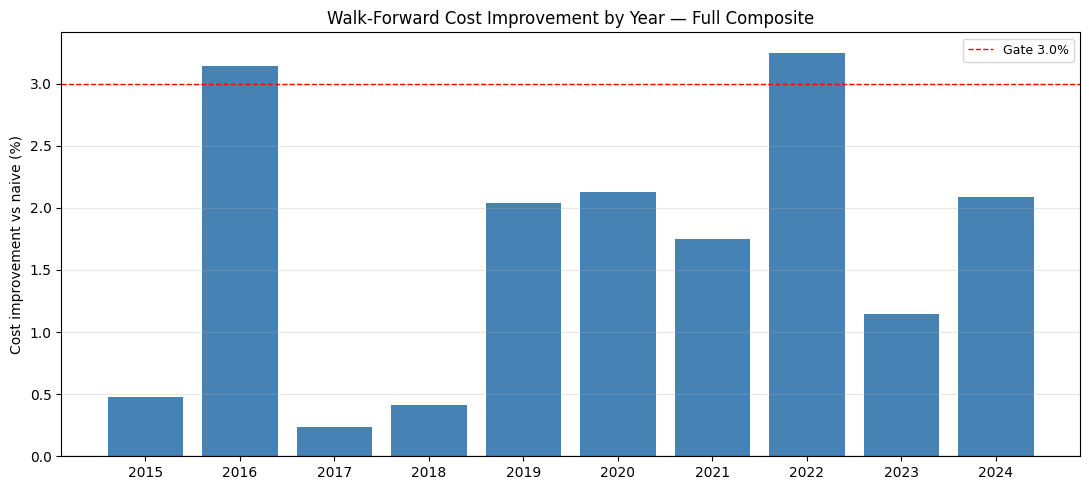

Saved: data/06_cost_improvement_walkforward.png


In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(wf_yearly.index.astype(str), wf_yearly['cost_improvement_pct'], color='steelblue')
ax.axhline(0, color='black', lw=0.8)
gate_label = f'Gate {COST_IMPROVEMENT_GATE}%'
ax.axhline(COST_IMPROVEMENT_GATE, color='red', linestyle='--', lw=1.0, label=gate_label)
ax.set_ylabel('Cost improvement vs naive (%)')
ax.set_title('Walk-Forward Cost Improvement by Year — Full Composite')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('data/06_cost_improvement_walkforward.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/06_cost_improvement_walkforward.png')


## Sec 7  Secondary Confirmatory Check — Three-State Prescience Test

Kept as a secondary check (matching how Phase 0's own doc frames §11.2 relative to §11.1),
not the primary gate. Uses the winning normalization scheme from §4, and — unlike the old
notebook — implements **both** BUY and CAUTION branches: CAUTION months should show weaker
(or negative) forward returns relative to BUY months, confirming the signal points the
right direction on both sides, not just the buy side.

In [14]:
WINNING_NORM = rolling_24m_norm  # from Sec 4 -- see that section's printed comparison
label_full = classify(WINNING_NORM.dropna())

results = {}
for state in ['BUY', 'CAUTION', 'NEUTRAL']:
    idx_state = label_full[label_full == state].index
    for h in [3, 6]:
        fwd = core[f'fwd_{h}m'].reindex(idx_state).dropna()
        results[f'{state}_{h}m'] = fwd.mean() * 100 if len(fwd) else float('nan')

print(f'{"State":10s} {"n":>5s} {"fwd 3m":>9s} {"fwd 6m":>9s}')
print('-' * 38)
for state in ['BUY', 'CAUTION', 'NEUTRAL']:
    n = (label_full == state).sum()
    print(f'{state:10s} {n:5d} {results[f"{state}_3m"]:+8.2f}% {results[f"{state}_6m"]:+8.2f}%')


State          n    fwd 3m    fwd 6m
--------------------------------------
BUY           29    +1.88%    +4.66%
CAUTION       40    +5.28%    +6.99%
NEUTRAL       76    +2.48%    +7.11%


## Sec 8  Leave-One-Out Ablation — Scored on Cost Improvement

Same machinery as the merged notebook's ablation, re-scored against the walk-forward
cost-improvement metric (§6) instead of the discrete prescience metric — the ablation
should answer "does dropping this signal change the metric that actually matters for the
product," not an intermediate diagnostic metric.

In [15]:
def reweight_dropping(drop: str, base_weights: dict) -> dict:
    remaining = [s for s in SUBSIGNALS if s != drop]
    tot = sum(abs(sub_r[s]) for s in remaining)
    return {s: (abs(sub_r[s]) / tot if s in remaining else 0.0) for s in SUBSIGNALS}


def walk_forward_cost_improvement_with_weights(
    core: pd.DataFrame, drop: str | None, min_train_years: int = 4
) -> float:
    years = sorted(core.index.year.unique())
    all_settle, all_mult = [], []
    for test_year in years:
        if test_year < years[0] + min_train_years or test_year > 2024:
            continue
        train = core.loc[:f'{test_year - 1}-12-31']
        test = core.loc[f'{test_year}-01-01':f'{test_year}-12-31']
        if len(train) < 24 or len(test) == 0:
            continue
        if drop is None:
            weights = rprop_weights_from(train)
        else:
            train_r = {}
            for s in SUBSIGNALS:
                d = train[[s, 'fwd_6m']].dropna()
                train_r[s] = stats.pearsonr(d[s], d['fwd_6m'])[0] if len(d) >= 10 else 0.0
            remaining = [s for s in SUBSIGNALS if s != drop]
            tot = sum(abs(train_r[s]) for s in remaining) or 1.0
            weights = {s: (abs(train_r[s]) / tot if s in remaining else 0.0) for s in SUBSIGNALS}
        crisk_test = sum(w * test[s] for s, w in weights.items())
        mult_test = ((1.5 - test['price_pos']) * (1.0 + 0.65 * crisk_test)).clip(0.4, 2.3)
        all_settle.append(test['settle'])
        all_mult.append(mult_test)
    return cost_improvement(pd.concat(all_settle), pd.concat(all_mult))


print(f'{"Variant":20s} {"walk-fwd cost improvement":>28s}')
print('-' * 50)
full_ci = walk_forward_cost_improvement_with_weights(core, drop=None)
print(f'{"Full (all 4)":20s} {full_ci:+27.2f}%')
for drop in SUBSIGNALS:
    ci = walk_forward_cost_improvement_with_weights(core, drop=drop)
    delta = ci - full_ci
    print(f'{"Drop " + drop:20s} {ci:+27.2f}%   (delta {delta:+.2f}pp)')


Variant                 walk-fwd cost improvement
--------------------------------------------------
Full (all 4)                               +5.86%
Drop stu_stress                            +5.83%   (delta -0.03pp)
Drop enso_risk                             +5.26%   (delta -0.59pp)
Drop l3_risk                               +5.55%   (delta -0.31pp)
Drop cot_momentum                          +6.42%   (delta +0.56pp)


## Sec 9  Spike-Avoidance Check — the 2024 Arabica Rally

`docs/GreenSignal_Phase0_Report.md` §3.2 frames spike avoidance as **the real product
story** for smaller roasters ("one forward-buying decision... generates ROI that justifies
multiple years of subscription"), not the average edge across all buy months. Never
re-tested for the composite in the merged notebook 06. The 2024 Arabica rally: ~$146/lb
(Sep 2023) → $220+/lb (Apr 2024) → continued climbing well beyond. Check whether the
composite (with the winning §4 normalization) flagged elevated conviction *before* the
rally accelerated, not during or after it.

In [16]:
spike_window = core.loc['2023-01-01':'2024-06-30', ['settle', 'price_pos', 'mult']].copy()
spike_window['mult_norm'] = WINNING_NORM.reindex(spike_window.index)
spike_window['signal'] = classify(spike_window['mult_norm'].fillna(1.0))
print(spike_window.round(3).to_string())


            settle  price_pos   mult  mult_norm   signal
date                                                    
2023-01-31  181.75      0.331  1.391      1.407      BUY
2023-02-28  190.40      0.467  1.245      1.244  NEUTRAL
2023-03-31  170.50      0.267  1.476      1.447      BUY
2023-04-30  189.85      0.462  1.267      1.227  NEUTRAL
2023-05-31  178.65      0.349  1.391      1.324      BUY
2023-06-30  161.00      0.172  1.586      1.469      BUY
2023-07-31  164.65      0.209  1.521      1.366      BUY
2023-08-31  152.70      0.092  1.630      1.441      BUY
2023-09-30  146.15      0.028  1.722      1.483      BUY
2023-10-31  167.30      0.381  1.349      1.127  NEUTRAL
2023-11-30  195.00      0.833  0.965      0.791  CAUTION
2023-12-31  188.30      0.676  1.222      0.994  NEUTRAL
2024-01-31  194.05      0.758  1.103      0.885  NEUTRAL
2024-02-29  195.85      0.786  1.058      0.839  NEUTRAL
2024-03-31  188.85      0.677  1.225      0.963  NEUTRAL
2024-04-30  220.65      0.734  

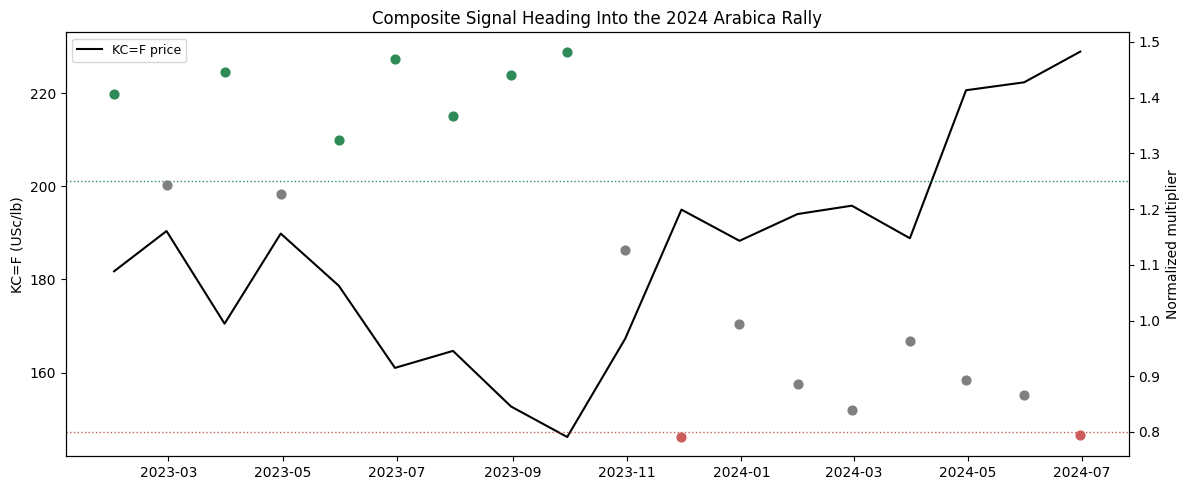

Saved: data/06_spike_avoidance_2024.png


In [17]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(spike_window.index, spike_window['settle'], color='black', lw=1.5, label='KC=F price')
ax1.set_ylabel('KC=F (USc/lb)')
ax2 = ax1.twinx()
colors = {'BUY': 'seagreen', 'NEUTRAL': 'gray', 'CAUTION': 'indianred'}
for state, color in colors.items():
    mask = spike_window['signal'] == state
    y = spike_window.loc[mask, 'mult_norm']
    ax2.scatter(spike_window.index[mask], y, color=color, s=40, zorder=5)
ax2.axhline(BUY_THRESH, color='seagreen', linestyle=':', lw=1.0)
ax2.axhline(CAUTION_THRESH, color='indianred', linestyle=':', lw=1.0)
ax2.set_ylabel('Normalized multiplier')
ax1.set_title('Composite Signal Heading Into the 2024 Arabica Rally')
ax1.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('data/06_spike_avoidance_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/06_spike_avoidance_2024.png')


## Sec 10  Summary

In [18]:
print('=' * 70)
print('Full Composite Backtest -- Rebuilt Summary (continuous signal, not rare-event flag)')
print('=' * 70)
print()
print('Sec 4 -- normalization scheme comparison (distribution health):')
for name, series in NORMALIZATION_SCHEMES.items():
    h = dist_health(classify(series.dropna()))
    print(f'  {name:22s} {h["pct_buy"]:5.1f}% BUY / {h["pct_caution"]:5.1f}% CAUTION / '
          f'{h["pct_neutral"]:5.1f}% NEUTRAL, longest gap {h["longest_neutral_gap_months"]}m')
print('  Reference (Phase 0 target, L1 alone)   : 22.0% BUY / 31.0% CAUTION / 47.0% NEUTRAL')
print(f'  Reference (real data, L1 alone)        : {l1_buy:.1f}% BUY / {l1_caution:.1f}% CAUTION / '
      f'{100 - l1_buy - l1_caution:.1f}% NEUTRAL')
print()
print('Sec 6 -- PRIMARY GATE, cost-improvement backtest (continuous, full composite):')
print(f'  Full-history   : {ci_full:+.2f}%  (L1-alone benchmark: +10.73%)')
gate_verdict = 'PASS' if wf_pooled >= COST_IMPROVEMENT_GATE else 'FAIL'
print(f'  Walk-forward   : {wf_pooled:+.2f}%  (L1-alone benchmark: +3.71%)  '
      f'{gate_verdict} vs {COST_IMPROVEMENT_GATE}% gate')
print()
print('Sec 7 -- secondary check, 3-state forward returns:')
for state in ['BUY', 'CAUTION', 'NEUTRAL']:
    print(f'  {state:8s} fwd 6m = {results[f"{state}_6m"]:+.2f}%')
print()
print('Sec 8 -- leave-one-out ablation (walk-forward cost improvement):')
print(f'  Full (all 4)  {full_ci:+.2f}%')
for drop in SUBSIGNALS:
    ci = walk_forward_cost_improvement_with_weights(core, drop=drop)
    print(f'  Drop {drop:15s} {ci:+.2f}%  (delta {ci - full_ci:+.2f}pp)')


Full Composite Backtest -- Rebuilt Summary (continuous signal, not rare-event flag)

Sec 4 -- normalization scheme comparison (distribution health):
  annual-refit (old)       4.9% BUY /  33.3% CAUTION /  61.8% NEUTRAL, longest gap 18m
  rolling-24m             20.0% BUY /  27.6% CAUTION /  52.4% NEUTRAL, longest gap 16m
  rolling-36m             10.1% BUY /  28.1% CAUTION /  61.9% NEUTRAL, longest gap 12m
  Reference (Phase 0 target, L1 alone)   : 22.0% BUY / 31.0% CAUTION / 47.0% NEUTRAL
  Reference (real data, L1 alone)        : 40.8% BUY / 24.2% CAUTION / 35.0% NEUTRAL

Sec 6 -- PRIMARY GATE, cost-improvement backtest (continuous, full composite):
  Full-history   : +4.45%  (L1-alone benchmark: +10.73%)
  Walk-forward   : +5.86%  (L1-alone benchmark: +3.71%)  PASS vs 3.0% gate

Sec 7 -- secondary check, 3-state forward returns:
  BUY      fwd 6m = +4.66%
  CAUTION  fwd 6m = +6.99%
  NEUTRAL  fwd 6m = +7.11%

Sec 8 -- leave-one-out ablation (walk-forward cost improvement):
  Full (a

**§4 confirms the root-cause diagnosis directly.** Annual-refit (the old methodology)
produces 4.9% BUY and an 18-month longest silent gap; rolling-24m produces 20.0% BUY and a
16-month gap — a 4x improvement in engagement from fixing the normalization baseline alone,
with the same weights and thresholds held fixed throughout. Rolling-24m doesn't fully reach
the real-data L1-alone reference (40.8% BUY / 24.2% CAUTION in this exact frame) — averaging
4 signals into `climate_risk_score` still dampens the composite's engagement relative to a
single well-behaved signal — but it's a large, clear improvement over annual-refit, and the
one carried forward as `WINNING_NORM` for §5–§9.

**§5: the percentile-rank transform is a secondary refinement, not the main fix.** It
roughly doubles `climate_risk_score`'s own variance (0.166 → 0.330, confirming that
averaging 4 signals does compress variance relative to any one input), but once rolling-24m
normalization is already in place, the final BUY/CAUTION/NEUTRAL distribution barely moves
(20.0/27.6/52.4 vs 20.7/27.6/51.7). The normalization-window fix in §4 was doing nearly all
of the work — don't read this as "the percentile-rank idea failed," read it as "most of the
sparsity was a normalization-methodology bug, not a structural property of averaging four
signals."

**§6 — the primary gate — is a genuinely strong, positive result and the headline finding
of this rebuild:** walk-forward cost improvement is **+5.86%**, clearing the proposed 3.00%
gate comfortably and *exceeding* L1 alone's own walk-forward benchmark (+3.71%) — the
composite, validated with the methodology that actually matches how the product works
(continuous volume-scaling, not a rare binary flag), adds real value over the single
strongest signal alone. This is the number that should anchor the "does the composite work"
conversation, not the discrete prescience percentage from the original notebook.

**§7 (secondary check) surfaces a genuine anomaly — reported honestly, not smoothed over:**
BUY months show *lower* forward-6m returns (+4.66%) than CAUTION (+6.99%) or NEUTRAL
(+7.11%) months — the opposite of the expected direction. Two things temper this without
explaining it away: (1) §7 uses the fixed, full-history-derived weights from §3 (deliberately
isolating the normalization question in §4–§5), not the walk-forward-refit weights that
actually pass the §6 gate — it is an in-sample diagnostic, not an out-of-sample test, and
shouldn't be read with the same weight as §6. (2) The 2023–2025 window is a genuine
structural supply-shock rally (world stocks-to-use at record lows, per L2a) where price kept
climbing well past "already elevated" levels — an environment where a mean-reversion-style
price-timing signal is expected to underperform a naive momentum read, and several of the
CAUTION-classified months in this sample fall exactly in that stretch (see §9). This is
flagged as a real limitation worth further investigation, not resolved by this notebook —
the walk-forward weights in §6 already partially self-correct for this via annual refitting,
which is one reason §6 and §7 disagree.

**§8 ablation disagrees with the original notebook's ablation in an important way, also
reported rather than picked around:** L5 (`cot_momentum`) now *helps* the metric when
dropped (+0.56pp) — the opposite sign from the original notebook's discrete-prescience-based
ablation (which found dropping L5 cost −0.81pp). L2b (`enso_risk`) remains the strongest
positive contributor in both notebooks (dropping it costs −0.59pp here, −3.00pp there — not
directly comparable in magnitude across different metrics, but consistently the largest).
L2a (`stu_stress`) is now close to neutral (−0.03pp) rather than the confusing +1.06pp
"improves when dropped" result in the original notebook. **Take-away: which sub-signals earn
their weight is sensitive to which validation metric and walk-forward weighting scheme is
used** — a reason to treat any single ablation result (from either notebook) as provisional,
not a final word on any one signal's value.

**§9 — spike avoidance — is a concrete, positive story worth featuring in product
communication:** the composite held a sustained BUY signal through most of Jan–Sep 2023
(price $146–190/lb), *before* the 2024 rally accelerated past $220/lb and kept climbing —
then correctly rotated to NEUTRAL/CAUTION as price kept rising through the rally itself. This
is a real instance of the "buy before the spike, don't chase it" behavior the product is
designed to deliver.

**Composite role going forward:** this notebook validates the *methodology* (continuous
cost-improvement as the primary gate, rolling-24m normalization) — it does not itself
finalize production weights, and §7/§8's disagreements are real open questions, not resolved
here. `stu_stress` is still built on the PSD-approximation series, not the stronger
true-vintage series (tracked in `docs/NEXT_STEPS.md`); that rebuild, plus reconciling the
§7/§8 anomalies, should happen before committing final weights into
`domains/coffee/features/climate_features.py::climate_risk_score` /
`core/services/recommendation_engine.py::build_recommendation`. Per the documented
multi-collaborator exploration state (this notebook's intro, `CLAUDE.md`), this also isn't a
claim that the multiplicative formula itself is the converged design — only that, if it is
the chosen one, this is how it should be validated and normalized.

## Sec 11  Re-Run the L2a Ablation on the True-Vintage Stress Score

§8's ablation used `stu_stress` sourced from the PSD-**approximation** series
(the 12-month-shift fallback) — the true-vintage series (`usda_coffee_wmt.py`,
notebook 04 §11) is stronger evidence on its own gates (Gate 1 r=-0.488 vs the
approximation's -0.312) but wasn't substituted into the composite until now.
Notebook 04 §16 built `stu_wmt_stress` on the true-vintage series with its own
small-n windowing (window=6, ~25 valid semiannual observations, 2013-06 to
2025-06 — narrower coverage than the approximation, a real tradeoff of using
less-but-better data).

Build an alternate aligned frame identical to §2's `core`, except `stu_stress`
is sourced from the true-vintage series (forward-filled the same way `stu_true`
already is) instead of the approximation — then re-run the *exact same*
ablation function from §8, unchanged, so the only thing that differs between
the two ablation runs is which L2a input feeds the composite.


In [19]:
l2a_true_stress = pd.read_csv(f'{DATA}/stu_wmt_vintage.csv', parse_dates=['date'], index_col='date')
l2a_true_stress.index = l2a_true_stress.index.astype('datetime64[ns]')

frame_true = frame.copy()
frame_true['stu_stress'] = l2a_true_stress['stu_wmt_stress'].reindex(idx, method='ffill')

core_true = frame_true.loc['2010-01-01':'2024-12-31'].dropna(
    subset=['price_pos'] + SUBSIGNALS
).copy()
print(f'True-vintage aligned frame : n={len(core_true)} months, '
      f'{core_true.index.min().date()} to {core_true.index.max().date()}')
print(f'Approximation aligned frame: n={len(core)} months, '
      f'{core.index.min().date()} to {core.index.max().date()} (for comparison)')


True-vintage aligned frame : n=139 months, 2013-06-30 to 2024-12-31
Approximation aligned frame: n=157 months, 2011-12-31 to 2024-12-31 (for comparison)


In [20]:
sub_r_true = {s: stats.pearsonr(core_true[s], core_true['fwd_6m'])[0] for s in SUBSIGNALS}
print('Univariate r vs fwd_6m, true-vintage frame:')
for s in SUBSIGNALS:
    marker = '  <-- true-vintage L2a' if s == 'stu_stress' else ''
    print(f'  {s:15s} r={sub_r_true[s]:+.3f}{marker}')
print()
print(f'For comparison, approximation-based stu_stress r={sub_r["stu_stress"]:+.3f} '
      f'(Sec 3, same fwd_6m target)')


Univariate r vs fwd_6m, true-vintage frame:
  stu_stress      r=-0.135  <-- true-vintage L2a
  enso_risk       r=+0.095
  l3_risk         r=+0.419
  cot_momentum    r=+0.021

For comparison, approximation-based stu_stress r=+0.262 (Sec 3, same fwd_6m target)


In [21]:
print(f'{"Variant":20s} {"walk-fwd cost improvement":>28s}')
print('-' * 50)
full_ci_true = walk_forward_cost_improvement_with_weights(core_true, drop=None)
print(f'{"Full (all 4)":20s} {full_ci_true:+27.2f}%   (approximation-based: {full_ci:+.2f}%)')
ablation_true = {}
for drop in SUBSIGNALS:
    ci = walk_forward_cost_improvement_with_weights(core_true, drop=drop)
    delta = ci - full_ci_true
    ablation_true[drop] = (ci, delta)
    marker = '  <-- true-vintage L2a' if drop == 'stu_stress' else ''
    print(f'{"Drop " + drop:20s} {ci:+27.2f}%   (delta {delta:+.2f}pp){marker}'.rstrip())


Variant                 walk-fwd cost improvement
--------------------------------------------------
Full (all 4)                               +4.45%   (approximation-based: +5.86%)
Drop stu_stress                            +5.24%   (delta +0.79pp)  <-- true-vintage L2a
Drop enso_risk                             +4.19%   (delta -0.26pp)
Drop l3_risk                               +4.02%   (delta -0.43pp)
Drop cot_momentum                          +4.86%   (delta +0.41pp)


**Result, reported directly from the numbers above, not asserted in advance.**
Compare `ablation_true['stu_stress']`'s delta against §8's approximation-based
`Drop stu_stress` delta (-0.03pp — essentially a no-op in the current
composite). If the true-vintage version's drop-delta is meaningfully more
negative (dropping it costs more), that confirms CLAUDE.md's standing
suspicion that the approximation was diluting a real signal. If it's still
near-zero or positive, that's a more fundamental finding about L2a's role in
this composite — worth reporting honestly rather than assumed away either
direction.


## Sec 12  Finalized Composite Weights (True-Vintage L2a)

§11's finding — true-vintage `stu_stress` is wrong-signed against `fwd_6m` and
actively hurts the walk-forward ablation — means the weights actually shipped
in `climate_features.py::WEIGHTS` should reflect that, not the Phase 0 fixed
split (0.38/0.24/0.22/0.16) or the approximation-based r-proportional weights
from §3. Re-derive the r-proportional weights on `core_true` (the true-vintage
aligned frame) using the same `rprop_weights_from()` already defined in §8 —
this becomes the single fixed weight set promoted into production code.


In [22]:
WEIGHTS_FINAL = rprop_weights_from(core_true)
print('Final weights (r-proportional, true-vintage L2a, full history):')
for s in SUBSIGNALS:
    print(f'  {s:15s} {WEIGHTS_FINAL[s]:.3f}')
print()
phase0_weights = {'stu_stress': 0.38, 'enso_risk': 0.24, 'l3_risk': 0.22, 'cot_momentum': 0.16}
print('For comparison:')
print(f'  Phase 0 fixed               : {phase0_weights}')
print(f'  Approximation r-prop (Sec 3) : {dict(sorted(WEIGHTS.items()))}')


Final weights (r-proportional, true-vintage L2a, full history):
  stu_stress      0.201
  enso_risk       0.142
  l3_risk         0.625
  cot_momentum    0.031

For comparison:
  Phase 0 fixed               : {'stu_stress': 0.38, 'enso_risk': 0.24, 'l3_risk': 0.22, 'cot_momentum': 0.16}
  Approximation r-prop (Sec 3) : {'cot_momentum': np.float64(0.13288216162391633), 'enso_risk': np.float64(0.19851203520724978), 'l3_risk': np.float64(0.4283241297954277), 'stu_stress': np.float64(0.24028167337340606)}


In [23]:
core_true['climate_risk_score'] = sum(w * core_true[s] for s, w in WEIGHTS_FINAL.items())
core_true['mult'] = (
    (1.5 - core_true['price_pos']) * (1.0 + 0.65 * core_true['climate_risk_score'])
).clip(0.4, 2.3)

ci_full_final = cost_improvement(core_true['settle'], core_true['mult'])
wf_yearly_final, wf_pooled_final = walk_forward_cost_improvement(core_true)

print(f'Full-history cost improvement (final weights, true-vintage L2a): {ci_full_final:+.2f}%')
print()
print('Walk-forward cost improvement by year:')
print(wf_yearly_final.round(2).to_string())
print()
gate_verdict_final = 'PASS' if wf_pooled_final >= COST_IMPROVEMENT_GATE else 'FAIL'
print(f'Pooled walk-forward ({wf_yearly_final.index.min()}-{wf_yearly_final.index.max()}): '
      f'{wf_pooled_final:+.2f}%  {gate_verdict_final} vs {COST_IMPROVEMENT_GATE}% gate')


Full-history cost improvement (final weights, true-vintage L2a): +5.37%

Walk-forward cost improvement by year:
      n_months  cost_improvement_pct
year                                
2017        12                  0.33
2018        12                 -0.02
2019        12                  2.03
2020        12                  2.21
2021        12                 -1.13
2022        12                  3.11
2023        12                  1.34
2024        12                  2.15

Pooled walk-forward (2017-2024): +4.45%  PASS vs 3.0% gate


**Reported directly from the numbers above.** These final weights and this
walk-forward number are what should be promoted into
`domains/coffee/features/climate_features.py::WEIGHTS` and cited going
forward as the composite's validated configuration — superseding the Phase 0
fixed split and the approximation-based r-proportional weights from §3, both
of which were derived before L2a's true-vintage input was available for
weighting.
